<b> Notebook to evaluate integration methods

The first two sections just calculate UMAPs to visualize the data and color by batch variable / cell type to inspect how good the embedding is
The steps are always:
1. load dataset
2. load annotation
3. subsample dataset (since calculateing neighbors and umap requires a lot of time)
4. calculate neighbors and umap
5. create umap plot (set variable you want to color by)
6. Calculate cLISI or iLISI score (optional since the last section calculates the benchmark metrics)



<b> Last section calculates benchmark metrics for integration evaluation using scib package

In [1]:
import scanpy as sc
import pandas as pd
import scib #.benchmark import Benchmarker, BioConservation, BatchCorrection # pip install --no-binary scib scib
import matplotlib.pyplot as plt
import anndata as ad

ModuleNotFoundError: No module named 'scanpy'

<b> Helper Methods (directly store plots by providing an output path "out_png")

In [2]:
def neighbors_umap(adata, use_rep=None):
    print(f"PP Neighbors")
    if use_rep:
        sc.pp.neighbors(adata, use_rep=use_rep)
    else:
        sc.pp.neighbors(adata)

    print(f"UMAP")
    sc.tl.umap(adata, min_dist=0.3, random_state=0)

def plot(adata, color, out_png=None, title=None, palette = None):
    if not title:
        title = f"UMAP imputed colored by {color}"
    if palette:
        ax = sc.pl.umap(
            adata, color=color, title = title, frameon=False,
            palette=palette,
            show=False, 
            return_fig=True
        )
    else: 
        ax = sc.pl.umap(
            adata, color=color, title = title, frameon=False, show=False, return_fig=True
        )
        
    plt.show()
    if out_png:
        ax.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(ax)


cell_type_palette = {'ABCs': '#023fa5',
 'Astrocytes': '#7d87b9',
 'Astroependymal': '#bec1d4',
 'BAMs': '#d6bcc0',
 'Bergmann': '#bb7784',
 'Choroid-Plexus': '#8e063b',
 'ECs': '#4a6fe3',
 'Ependymal': '#8595e1',
 'Immune-Other': '#b5bbe3',
 'Microglia': '#e6afb9',
 'Neurons-Dopa': '#e07b91',
 'Neurons-Gaba': '#d33f6a',
 'Neurons-Glut': '#11c638',
 'Neurons-Glyc-Gaba': '#8dd593',
 'Neurons-Granule-Immature': '#c6dec7',
 'Neurons-Other': '#ead3c6',
 'OECs': '#f0b98d',
 'OPCs': '#ef9708',
 'Oligodendrocytes': '#0fcfc0',
 'Pericytes': '#9cded6',
 'SMCs': '#d5eae7',
 'Tanycytes': '#f3e1eb',
 'Undefined': '#f6c4e1',
 'VLMCs': '#f79cd4'}

## Plot a single dataset

In [3]:
zhuang = sc.read("/p/project1/hai_fzj_bda/salg1/point_transformer/data/tangram/imputed_zhuang_subset6_20percent_60split.h5ad")

zhuang

AnnData object with n_obs × n_vars = 172459 × 5893
    obs: 'abc_sample_id', 'average_correlation_score', 'brain_section_label', 'brain_section_label_adata', 'class', 'class_color', 'cluster', 'cluster_alias', 'cluster_color', 'donor_genotype', 'donor_label', 'donor_sex', 'feature_matrix_label', 'neurotransmitter', 'neurotransmitter_color', 'parcellation_category', 'parcellation_category_color', 'parcellation_division', 'parcellation_division_color', 'parcellation_index', 'parcellation_organ', 'parcellation_organ_color', 'parcellation_structure', 'parcellation_structure_color', 'parcellation_substructure', 'parcellation_substructure_color', 'subclass', 'subclass_color', 'supertype', 'supertype_color', 'x', 'x_ccf', 'y', 'y_ccf', 'z', 'z_ccf', 'brain_section_numerical', 'dataset', 'batch', 'cluster_confidence_score', 'high_quality_transfer', 'subclass_confidence_score', 'uniform_density', 'rna_count_based_density'

In [4]:
annotations_df = pd.read_csv("/p/project1/hai_fzj_bda/salg1/cellseg-benchmark/data_dir/samples/zhuang/results/merfish/cell_type_annotation/adata_obs_annotated.csv")

annotations_df

,cluster_confidence_score,subclass_confidence_score,cell_id,cell_type_mmc_raw,cell_type_mmc_incl_low_quality,cell_type_mmc_is_mixed,cell_type_mmc_incl_mixed,cell_type_mmc_mixed_names,cell_type_mmc_runner_up_1,cell_type_mmc_runner_up_2,cell_type_mmc_runner_up_1_incl_low_quality,cell_type_mmc_runner_up_2_incl_low_quality,cell_type_mmc_rup1_diff_prob,cell_type_mmc_rup2_diff_prob,cell_type_mmc_is_low_quality
0,0.684491,0.943029,38542084966093731202691164843098659276-Zhuang-...,Neurons-Glut,Undefined,unique,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,0.46,0.47,undefined
1,0.818168,0.996349,183256764301191388575899679882178798208-Zhuang...,Neurons-Glut,Neurons-Glut,unique,Neurons-Glut,Neurons-Glut,Neurons-Glut,NaN,Neurons-Glut,NaN,0.94,1.00,mapped
2,0.628805,0.944719,37353846072841168055577846846204745147-Zhuang-...,Neurons-Glut,Undefined,unique,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,0.94,0.95,undefined
3,0.719644,0.907111,56522635880108955114956785931951865125-Zhuang-...,Neurons-Glut,Neurons-Glut,unique,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,0.07,0.21,mapped
4,0.560641,0.962062,114075972918310011122352881571035240931-Zhuang...,Neurons-Glut,Neurons-Glut,unique,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,Neurons-Glut,0.81,0.87,mapped
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3672595,0.968400,0.999992,48334166639954048971718884656455172980-Zhuang-...,Oligodendrocytes,Undefined,unique,Oligodendrocytes,Oligodendrocytes,OPCs,NaN,OPCs,NaN,0.98,1.00,undefined
3672596,0.767955,0.999981,284562224288011367616899126362183220647-Zhuang...,Oligodendrocytes,Oligodendrocytes,unique,Oligodendrocytes,Oligodendrocytes,NaN,NaN,NaN,NaN,1.00,1.00,mapped
3672597,0.615759,0.999989,23742542170614849195952622149723985602-Zhuang-...,Oligodendrocytes,Oligodendrocytes,unique,Oligodendrocytes,Oligodendrocytes,NaN,NaN,NaN,NaN,1.00,1.00,mapped
3672598,0.703177,0.999951,211936726904126684881357807683128485542-Zhuang...,Oligodendrocytes,Oligodendrocytes,unique,Oligodendrocytes,Oligodendrocytes,NaN,NaN,NaN,NaN,1.00,1.00,mapped


In [5]:
zhuang.obs["cell_id"] = zhuang.obs.index

sc.pp.subsample(zhuang, n_obs=100000)

In [6]:
zhuang.obs = pd.merge(
    zhuang.obs,
    annotations_df[["cell_id", "cell_type_mmc_raw"]],
    on="cell_id",
    how="left"    
)


/p/software/jurecadc/stages/2025/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [7]:
neighbors_umap(zhuang)

PP Neighbors


/p/project1/hai_fzj_bda/salg1/point_transformer/venvs/tangram/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 5893 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/p/project1/hai_fzj_bda/salg1/point_transformer/venvs/tangram/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP


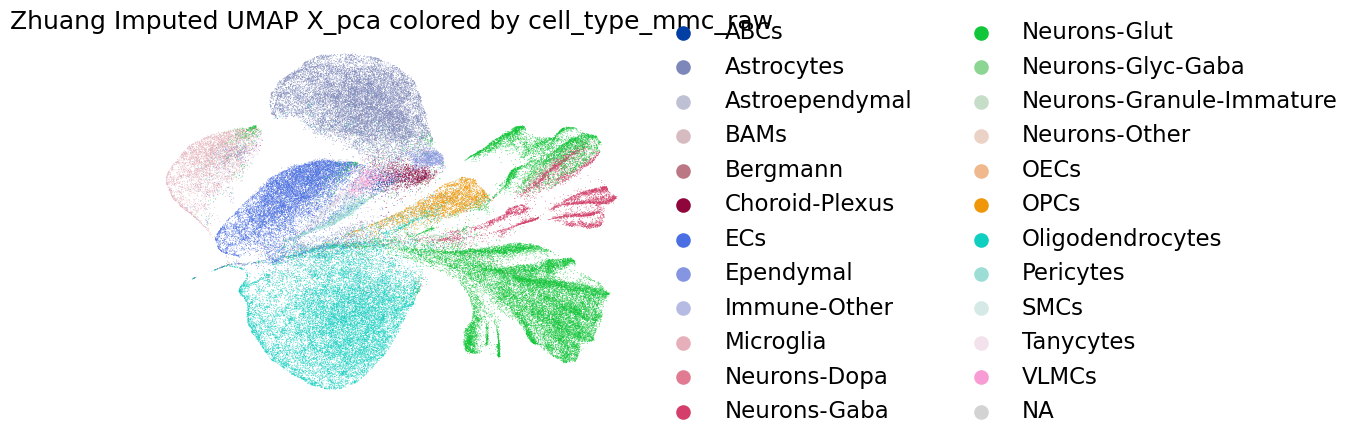

In [8]:
color = "cell_type_mmc_raw"
# color = "class"

title = f"Zhuang Imputed UMAP X_pca colored by {color}"
out_png = f"figures/split_increments/zhuang6_60split_imputed_xpca_{color}.png"
out_png = None # Comment out to store as png

plot(zhuang, color, out_png=out_png, title=title, palette=cell_type_palette)

In [9]:

zhuang_adata = zhuang.copy()
sc.pp.neighbors(zhuang_adata, use_rep="X_pca", n_neighbors=30)  # try 15, 50 too
sc.tl.umap(zhuang_adata, min_dist=0.4)

In [10]:
zhuang_adata_clisi = scib.metrics.clisi_graph(zhuang_adata, label_key="cell_type_mmc_raw",   type_="knn")
print("cLISI:", zhuang_adata_clisi) 

cLISI: 0.9999999999999996


## Plot multiple datasets to inspect integration

In [11]:
REFERENCE_PATH="/p/project1/hai_fzj_bda/salg1/point_transformer/data/harmony_symphony/reference_combined_zeng3_zhuang11_theta8.h5ad"
ref_zeng_zhuang = sc.read(REFERENCE_PATH)

ref_zeng_zhuang

AnnData object with n_obs × n_vars = 7300047 × 5934
    obs: 'abc_sample_id', 'brain_section_label', 'brain_section_label_adata', 'class', 'class_color', 'cluster', 'cluster_alias', 'cluster_color', 'donor_genotype', 'donor_label', 'donor_sex', 'feature_matrix_label', 'neurotransmitter', 'neurotransmitter_color', 'parcellation_category', 'parcellation_category_color', 'parcellation_division', 'parcellation_division_color', 'parcellation_index', 'parcellation_organ', 'parcellation_organ_color', 'parcellation_structure', 'parcellation_structure_color', 'parcellation_substructure', 'parcellation_substructure_color', 'subclass', 'subclass_color', 'supertype', 'supertype_color', 'x', 'x_ccf', 'y', 'y_ccf', 'z', 'z_ccf', 'brain_section_numerical', 'batch', 'dataset', 'slide_super_group', 'uniform_density', 'rna_count_based_density'
    var: 'mean', 'std'
    uns: 'harmony', 'layer_info', 'pca', 'symphony_reference_built'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'

In [12]:
annotated_zeng = pd.read_csv("/p/project1/hai_fzj_bda/salg1/cellseg-benchmark/data_dir/samples/zeng/results/merfish/cell_type_annotation/adata_obs_annotated.csv")
annotated_zhuang = pd.read_csv("/p/project1/hai_fzj_bda/salg1/cellseg-benchmark/data_dir/samples/zhuang/results/merfish/cell_type_annotation/adata_obs_annotated.csv")

annotated_zeng["cell_type"] = annotated_zeng["cell_type_mmc_raw"]
annotated_zhuang["cell_type"] = annotated_zhuang["cell_type_mmc_raw"]

annotated_zeng["cell_id"] = annotated_zeng["cell_id"].apply(lambda x: f"{x}-Zeng")
annotated_zhuang["cell_id"] = annotated_zhuang["cell_id"].apply(lambda x: f"{x}-Zhuang")

#cell_type_annotated_df = pd.concat([adata_isd.obs[["cell_id", "cell_type", "cell_type_mmc_raw_revised"]], annotated_zeng3[["cell_id", "cell_type_mmc_raw", "cell_type_mmc_raw_revised"]], annotated_zhuang11[["cell_id", "cell_type_mmc_raw_revised"]]])
cell_type_annotated_df = pd.concat([annotated_zeng[["cell_id", "cell_type"]], annotated_zhuang[["cell_id", "cell_type"]]])

set(ref_zeng_zhuang.obs.index) - set(cell_type_annotated_df.cell_id)

/tmp/ipykernel_997132/4042275273.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_zeng = pd.read_csv("/p/project1/hai_fzj_bda/salg1/cellseg-benchmark/data_dir/samples/zeng/results/merfish/cell_type_annotation/adata_obs_annotated.csv")


{'101677776542594605927505600750349748245-Zhuang-ABCA-1-Zhuang',
 '106254694823108974737657314350134412499-Zhuang-ABCA-1-Zhuang',
 '107150669839656491998916733034531895957-Zhuang-ABCA-1-Zhuang',
 '107178661406659669216766675837371688128-Zhuang-ABCA-2-Zhuang',
 '108680131514491004003004842097647973664-Zhuang-ABCA-2-Zhuang',
 '109271738558891647036087327974074669875-Zhuang-ABCA-1-Zhuang',
 '110245560794491179287733666502572349345-Zhuang-ABCA-1-Zhuang',
 '110298366137780355553496064152776701604-Zhuang-ABCA-1-Zhuang',
 '112197317711237715062064350308434326912-Zhuang-ABCA-2-Zhuang',
 '113462734190631956519127285001415684644-Zhuang-ABCA-2-Zhuang',
 '114773999111328363853476010800829430491-Zhuang-ABCA-2-Zhuang',
 '119089331146677803112868226387049618164-Zhuang-ABCA-2-Zhuang',
 '120094105749451394157633085161773756250-Zhuang-ABCA-1-Zhuang',
 '120513977083685252511052038066157499536-Zhuang-ABCA-2-Zhuang',
 '120841940757463408622808309286822192064-Zhuang-ABCA-2-Zhuang',
 '12269539988657199581161

In [13]:
ref_zeng_zhuang.obs["cell_id"] = ref_zeng_zhuang.obs.index

ref_zeng_zhuang.obs = pd.merge(
    ref_zeng_zhuang.obs,
    cell_type_annotated_df[["cell_id", "cell_type"]],
    on="cell_id",
    how="left"    
)
ref_zeng_zhuang

/p/software/jurecadc/stages/2025/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 7300047 × 5934
    obs: 'abc_sample_id', 'brain_section_label', 'brain_section_label_adata', 'class', 'class_color', 'cluster', 'cluster_alias', 'cluster_color', 'donor_genotype', 'donor_label', 'donor_sex', 'feature_matrix_label', 'neurotransmitter', 'neurotransmitter_color', 'parcellation_category', 'parcellation_category_color', 'parcellation_division', 'parcellation_division_color', 'parcellation_index', 'parcellation_organ', 'parcellation_organ_color', 'parcellation_structure', 'parcellation_structure_color', 'parcellation_substructure', 'parcellation_substructure_color', 'subclass', 'subclass_color', 'supertype', 'supertype_color', 'x', 'x_ccf', 'y', 'y_ccf', 'z', 'z_ccf', 'brain_section_numerical', 'batch', 'dataset', 'slide_super_group', 'uniform_density', 'rna_count_based_density', 'cell_id', 'cell_type'
    var: 'mean', 'std'
    uns: 'harmony', 'layer_info', 'pca', 'symphony_reference_built'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'P

In [14]:
sc.pp.subsample(ref_zeng_zhuang, n_obs=100000)

In [15]:
neighbors_umap(ref_zeng_zhuang, use_rep="X_pca_harmony")

PP Neighbors
UMAP


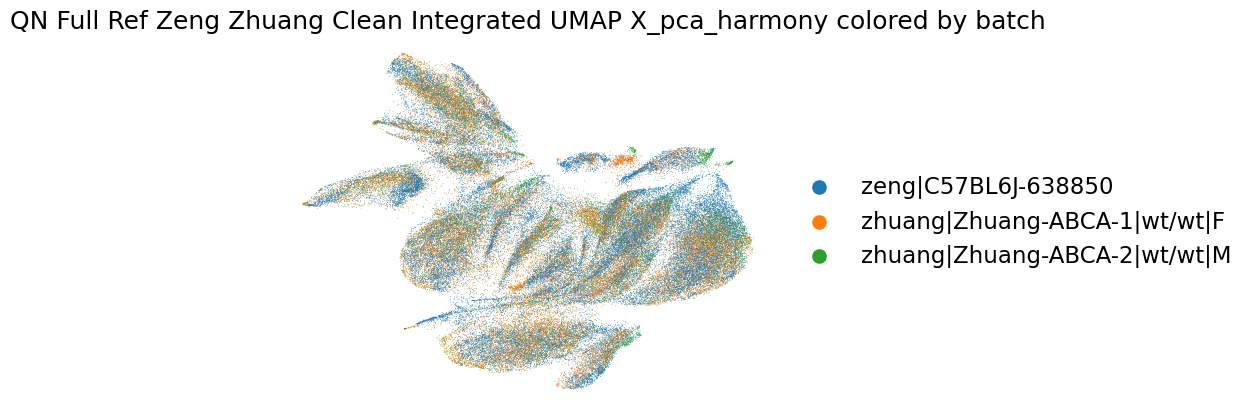

In [16]:

color = "batch"
title = f"QN Full Ref Zeng Zhuang Clean Integrated UMAP X_pca_harmony colored by {color}"
out_png = f"full_ref_figures/qn_full_ref_zeng_zhuang_clean_integrated_X_pca_harmony_{color}.png"
out_png = None # comment out to store figure


plot(ref_zeng_zhuang, color, out_png=out_png, title=title)

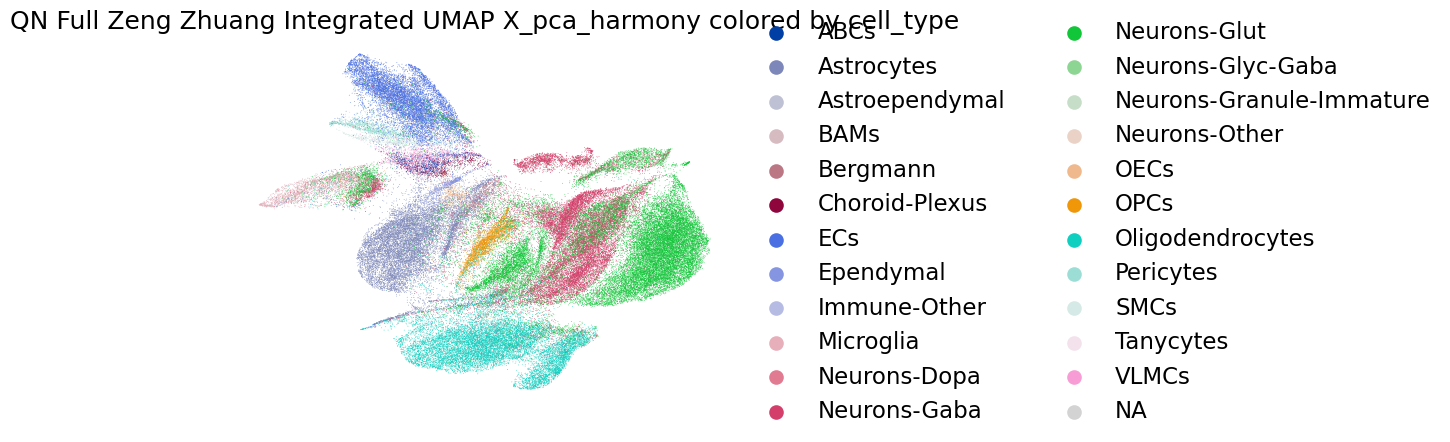

In [17]:
color = "cell_type"
title = f"QN Full Zeng Zhuang Integrated UMAP X_pca_harmony colored by {color}"
out_png = f"full_ref_figures/qn_full_ref_zeng_zhuang_integrated_X_pca_harmony_{color}.png"
out_png = None # comment out to store figure

plot(ref_zeng_zhuang, color, out_png=out_png, title=title, palette=cell_type_palette)

### Add third dataset

In [18]:
ISD_PATH = "/p/project1/hai_fzj_bda/salg1/point_transformer/data/harmony_symphony/query_mapped_hvg_isd_normed_20_full_reference.h5ad"
mapped_isd = sc.read_h5ad(ISD_PATH)

mapped_isd_clean = mapped_isd[mapped_isd.obs.cell_type_mmc_raw_revised != "Undefined"]

mapped_isd_clean.obs["cell_type"] = mapped_isd_clean.obs["cell_type_mmc_raw_revised"]


/tmp/ipykernel_997132/4161326766.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mapped_isd_clean.obs["cell_type"] = mapped_isd_clean.obs["cell_type_mmc_raw_revised"]


In [21]:
adata_combined = ad.concat(
    {"Ref (Zeng/Zhuang)": ref_zeng_zhuang, "Query(ISD)": mapped_isd_clean},
    label="symphony_dataset"
)

In [22]:
neighbors_umap(adata_combined, use_rep="X_pca_harmony")

PP Neighbors
UMAP


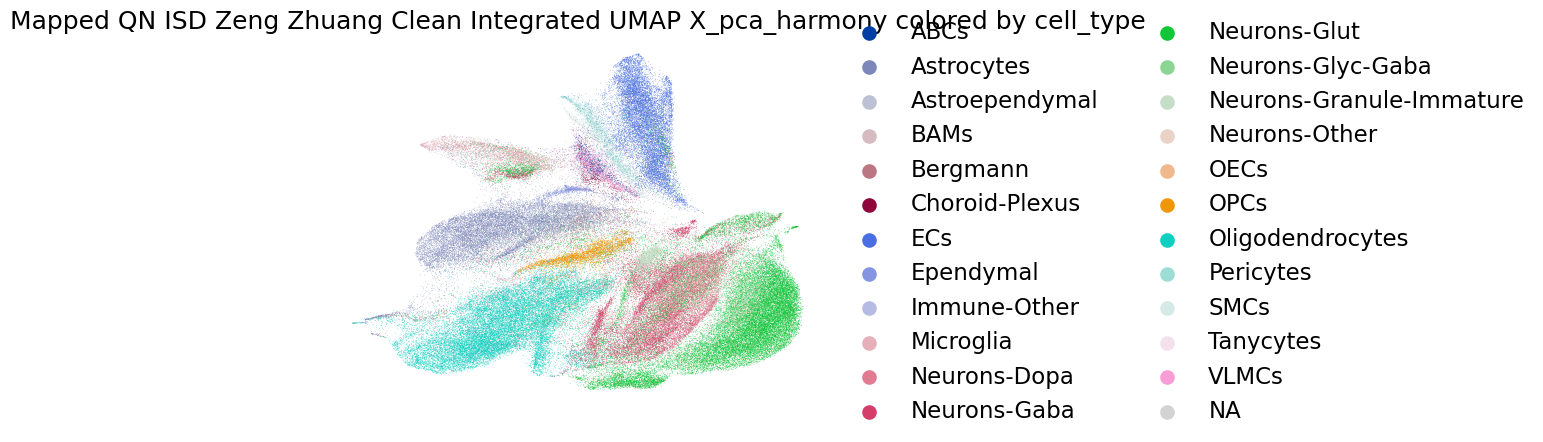

In [23]:
color = "cell_type"
title = f"Mapped QN ISD Zeng Zhuang Clean Integrated UMAP X_pca_harmony colored by {color}"
out_png = f"full_ref_figures/mapped_qn_isd_zeng_zhuang_integrated_X_pca_harmony_{color}.png"
out_png = None # png won't get stored

plot(adata_combined, color, out_png=out_png, title=title, palette=cell_type_palette)

In [24]:
adata_combined

AnnData object with n_obs × n_vars = 144321 × 5934
    obs: 'class', 'x', 'y', 'brain_section_numerical', 'batch', 'dataset', 'uniform_density', 'rna_count_based_density', 'cell_id', 'cell_type', 'symphony_dataset'
    uns: 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'X_pca_harmony', 'X_umap'
    obsp: 'distances', 'connectivities'

In [25]:
adata_combined.obs.cell_type.value_counts()

cell_type
Neurons-Glut                38569
Oligodendrocytes            23991
Neurons-Gaba                18602
Astrocytes                  16327
ECs                         12771
Neurons-Dopa                 5502
Neurons-Granule-Immature     4169
Microglia                    4082
OPCs                         3746
Neurons-Other                2908
Pericytes                    2255
Astroependymal               2202
VLMCs                        1966
SMCs                         1458
Neurons-Glyc-Gaba            1289
Ependymal                     981
ABCs                          860
Choroid-Plexus                702
Bergmann                      693
OECs                          631
BAMs                          400
Immune-Other                  146
Tanycytes                      68
Name: count, dtype: int64

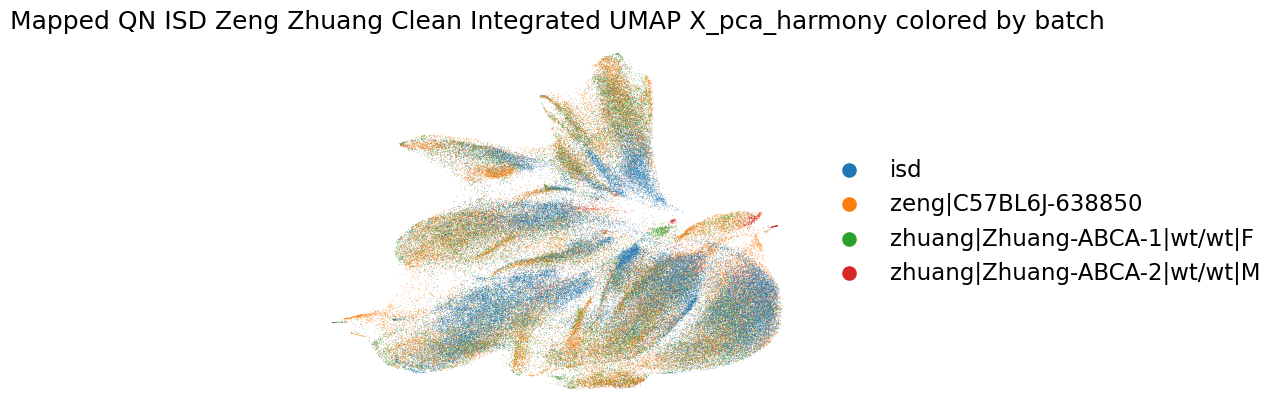

In [26]:
color = "batch"
title = f"Mapped QN ISD Zeng Zhuang Clean Integrated UMAP X_pca_harmony colored by {color}"
out_png = f"full_ref_figures/mapped_qn_isd_zeng_zhuang_integrated_X_pca_harmony_{color}.png"
out_png = None

plot(adata_combined, color, out_png=out_png, title=title)

In [27]:
import scib
adata = adata_combined.copy()
sc.pp.neighbors(adata, use_rep="X_pca_harmony", n_neighbors=30)  
sc.tl.umap(adata, min_dist=0.4)


ilisi = scib.metrics.ilisi_graph(adata, batch_key="dataset", type_="knn")
print("iLISI:", ilisi)

IOStream.flush timed out


iLISI: 0.5049492456799589


In [28]:
clisi = scib.metrics.clisi_graph(adata, label_key="cell_type",   type_="knn")
print("cLISI:", clisi) 

cLISI: 0.983180336877822


## Calculate scib benchmark metrics

<b> The scib metrics package calculates multiple metrics to evaluate how good the integration of multiple datasets works.

paper: https://www.nature.com/articles/s41592-021-01336-8

docs: https://scib-metrics.readthedocs.io/en/stable/index.html

github: https://github.com/yoseflab/scib-metrics



In [30]:
from scib_metrics.benchmark import Benchmarker #pip install scib-metrics

In [40]:
adata_combined.obs["cell_type_string"] = adata_combined.obs["cell_type"].astype("str")

In [41]:
bm = Benchmarker(
    adata_combined,
    batch_key="batch",
    label_key="cell_type_string",
    embedding_obsm_keys=["X_pca_harmony"],
    n_jobs=-1,
)
bm.benchmark()


/p/project1/hai_fzj_bda/salg1/point_transformer/venvs/tangram/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
rics:  60%|██████    | 6/10 [01:44<00:55, 13.79s/it, Batch correction: ilisi_knn]
/p/project1/hai_fzj_bda/salg1/point_transformer/venvs/tangram/lib/python3.12/site-packages/scib_metrics/metrics/_kbet.py:182: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  idx_nonan = np.flatnonzero(np.in1d(labs, comp_size[comp_size >= comp_size_thresh].index))
/p/project1/hai_fzj_bda/salg1/point_transformer/venvs/tangram/lib/python3.12/site-packages/scib_metrics/metrics/_kbet.py:182: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  idx_nonan = np.flatnonzero(n

INFO     nan consists of a single batch or is too small. Skip.                                                     



rics:  70%|███████   | 7/10 [03:15<01:57, 39.00s/it, Batch correction: kbet_per_label]
/p/project1/hai_fzj_bda/salg1/point_transformer/venvs/tangram/lib/python3.12/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings: 100%|██████████| 1/1 [03:18<00:00, 198.64s/it]tch correction: pcr_comparison]

                                                                                      

In [45]:
bm.get_results()


,Isolated labels,KMeans NMI,KMeans ARI,Silhouette label,cLISI,BRAS,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total
Embedding,,,,,,,,,,,,,
X_pca_harmony,0.683435,0.435033,0.221418,0.49133,0.991708,0.747775,0.242441,0.304761,0.805223,0.759211,0.571882,0.564585,0.567504
Metric Type,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Batch correction,Batch correction,Batch correction,Batch correction,Batch correction,Aggregate score,Aggregate score,Aggregate score


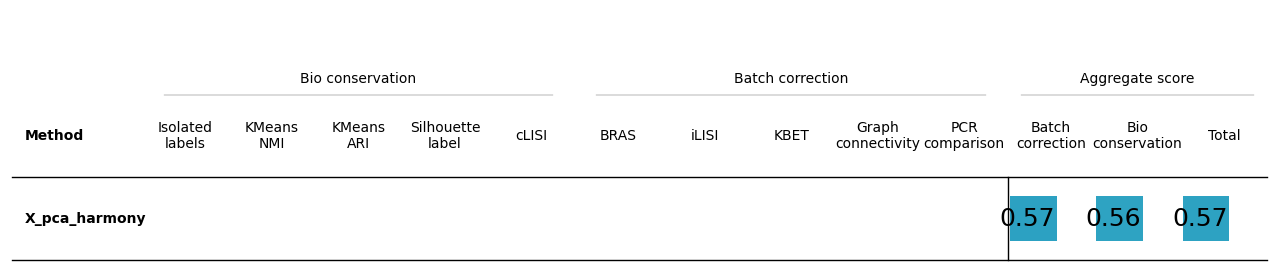

In [46]:
bm.plot_results_table()
